## Code for training model:
This code is for trianing mask rcnn model using the detectron2 github. For this change the file paths of coco dataset. (The dataset here was creating using labelme and then labelmetococo function was used to convert it to the proper dataset.) 

To Use with a Different Dataset or Save Location, Change These:

1. COCO annotation files:
   register_coco_instances(..., "path/to/pixel/masks.json", ...)
   register_coco_instances(..., "path/to/validation/pixel/masks.json", ...)
   → Change these paths to point to your COCO-format JSON label files.

2. Image folders:
   → Update the corresponding image folder paths in each `register_coco_instances()` call:
   - Train images: "path/to/training/images"
   - Val images:   "path/to/validation/images"

3. Model output directory:
   cfg.OUTPUT_DIR = "./Models"
   → Set where the trained model and config will be saved.

4. Training parameters (optional tweaks):
   - Learning rate:         cfg.SOLVER.BASE_LR = 0.00025
   - Batch size:            cfg.SOLVER.IMS_PER_BATCH = 4
   - Number of iterations:  cfg.SOLVER.MAX_ITER = 10000
   - Augmentations are applied in `custom_mapper()` and include brightness, contrast, saturation, lighting, and flips.

What it does:
- Sets up GPU/torch environment and registers COCO-style datasets.
- Configures and augments training using `CustomTrainer`.
- Trains a Detectron2 Mask R-CNN model on a 1-class segmentation problem.
- Saves the trained model and configuration YAML to the output directory.
- Loads the trained model and runs inference on a validation image with visualization.


In [1]:
import os, traceback

print("1) Current working dir:", os.getcwd())

# 2) Check nvidia-smi (only works if Jupyter allows shell)
try:
    smi = !nvidia-smi --query-gpu=name,memory.total --format=csv,noheader
    print("2) nvidia-smi:", smi.s)
except Exception as e:
    print("2) nvidia-smi failed:", e)

# 3) Inspect torch and CUDA
try:
    import torch
    print("3) torch.__version__     =", torch.__version__)
    print("   torch.version.cuda    =", torch.version.cuda)
    print("   torch.backends.cudnn.enabled =", torch.backends.cudnn.enabled)
    print("   torch.cuda.is_available()   =", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("   torch.cuda.device_count()   =", torch.cuda.device_count())
        print("   torch.cuda.get_device_name(0)=", torch.cuda.get_device_name(0))
        # Try a tiny tensor on GPU
        x = torch.randn(2,2).cuda()
        print("   GPU tensor OK:", x)
    else:
        print("   CUDA is not available → will use CPU only")
except Exception as e:
    print("3) Error initializing torch/CUDA:")
    traceback.print_exc()

print("\nIf everything above succeeds, then the crash must be later (e.g. when Detectron2 builds the model).")


1) Current working dir: C:\BLENDER\BubbleID\Code
2) nvidia-smi: NVIDIA RTX A4500, 20470 MiB
3) torch.__version__     = 2.5.1
   torch.version.cuda    = 11.8
   torch.backends.cudnn.enabled = True
   torch.cuda.is_available()   = True
   torch.cuda.device_count()   = 1
   torch.cuda.get_device_name(0)= NVIDIA RTX A4500
   GPU tensor OK: tensor([[ 1.6278,  0.1393],
        [ 1.1370, -1.7608]], device='cuda:0')

If everything above succeeds, then the crash must be later (e.g. when Detectron2 builds the model).


In [2]:
import os
#os.environ["CUDA_VISIBLE_DEVICES"] = "1" # For multiple gpu
os.environ.pop("CUDA_VISIBLE_DEVICES", None) # For 1 gpu

In [1]:
# Import Libraries:
import torch, detectron2
from detectron2.utils.logger import setup_logger
setup_logger()
from detectron2.data import transforms as T
# import some common libraries
import numpy as np
import os, json, cv2, random

# import some common detectron2 utilities
from detectron2 import model_zoo, structures
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog, DatasetMapper

from detectron2.data.datasets import register_coco_instances

C:\Users\Lab_Staff\anaconda3\envs\BubbleID\lib\site-packages\detectron2\model_zoo\model_zoo.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
#register_coco_instances("my_dataset_train", {}, "./MatlabTraining/Data/train.json","")
#register_coco_instances("my_dataset_train", {}, "./train.json","") # old version
register_coco_instances("my_dataset_train", {}, "C:/BLENDER/Bubble ID Test/Labels/SaveData/Bubblina_bubble_coco.json","C:/BLENDER/BubbleID/Code/Bubblina/Frames") # My(olivia) version


#register_coco_instances("my_dataset_test", {}, "./test.json","") # old version
register_coco_instances("my_dataset_test", {}, "C:/BLENDER/Bubble ID Test/Labels/SaveData/validation_Bubblina_bubble_coco.json","C:/BLENDER/BubbleID/Code/Bubblina/Validation Frames") # My(olivia) version

In [5]:
train_metadata = MetadataCatalog.get("my_dataset_train")
train_dataset_dicts = DatasetCatalog.get("my_dataset_train")

[10/23 15:20:06 d2.data.datasets.coco]: Loaded 90 images in COCO format from C:/BLENDER/Bubble ID Test/Labels/SaveData/Bubblina_bubble_coco.json


In [6]:
val_metadata = MetadataCatalog.get("my_dataset_test")
val_dataset_dicts = DatasetCatalog.get("my_dataset_test")

[10/23 15:20:06 d2.data.datasets.coco]: Loaded 23 images in COCO format from C:/BLENDER/Bubble ID Test/Labels/SaveData/validation_Bubblina_bubble_coco.json


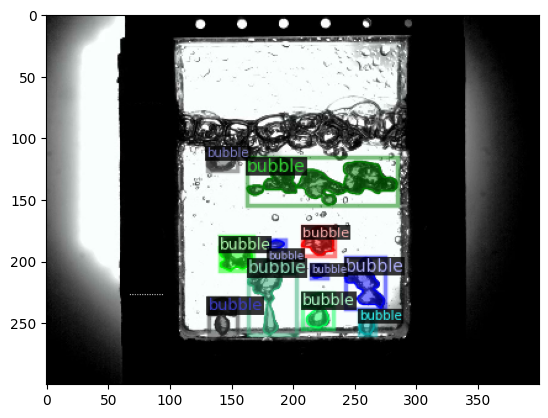

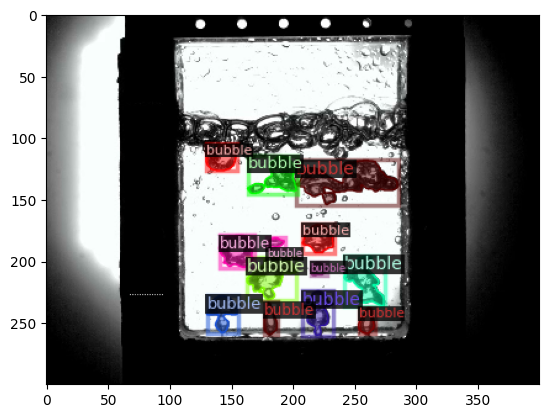

In [7]:
from matplotlib import pyplot as plt
for d in random.sample(train_dataset_dicts, 2):
    img = cv2.imread(d["file_name"])
    visualizer = Visualizer(img[:, :, ::-1], metadata=train_metadata, scale=0.5)
    vis = visualizer.draw_dataset_dict(d)
    plt.imshow(vis.get_image()[:, :, ::-1])
    plt.show()

In [5]:
from detectron2.config import get_cfg #Olivia Added
from detectron2 import model_zoo #Olivia Added
from detectron2.engine import DefaultTrainer
from detectron2.data import build_detection_train_loader #Olivia Added

# Fancy Ant
# Best AP50: 93.76015414677305
# Best params: {'lr': 0.0009373578118508284, 'weight_decay': 9.983896343720864e-06, 'batch_size': 4}

# Blender
# Best AP50: 49.08239598902773
# Best params: {'lr': 0.00912699610468898, 'weight_decay': 4.336561571305324e-06, 'batch_size': 4}

# Bubblina Water
# Best AP50: 96.40825803396086
# Best params: {'lr': 0.0006391244322775975, 'weight_decay': 1.99141356066116e-06, 'batch_size': 2}

# Bubblina SPT3
# Best AP50: 98.65320835113687
# Best params: {'lr': 0.0009024353018779585, 'weight_decay': 1.176128372816162e-05, 'batch_size': 4}

cfg = get_cfg()
cfg.OUTPUT_DIR = "./Models/Bubblina"
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
cfg.DATASETS.TRAIN = ("my_dataset_train",)
cfg.DATASETS.TEST = ()
cfg.DATALOADER.NUM_WORKERS = 4#2
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")  # Let training initialize from model zoo
#cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final_MATLAB1.pth")  # path to the model we just trained
cfg.MODEL.ANCHOR_GENERATOR.SIZES         = [[4], [8], [16], [32], [64]] #Olivia Added
cfg.MODEL.ANCHOR_GENERATOR.ASPECT_RATIOS = [[0.5, 1.0, 2.0]] #Olivia Added
cfg.INPUT.MIN_SIZE_TRAIN = (600, 800, 1000)   # randomly pick one short edge #Olivia Added
cfg.INPUT.MAX_SIZE_TRAIN = 1400 #Olivia Added
cfg.INPUT.MIN_SIZE_TEST  = 1000 #Olivia Added
cfg.SOLVER.IMS_PER_BATCH = 2 #2  # This is the real "batch size" commonly known to deep learning people
cfg.SOLVER.BASE_LR = 0.006834190875122807  # pick a good LR
cfg.SOLVER.WEIGHT_DECAY   = 9.289053154490953e-06
cfg.SOLVER.MAX_ITER = 5000 #1000    # 1000 iterations seems good enough for this dataset
cfg.SOLVER.STEPS = (7000, 9000) #[]        # do not decay learning rate
cfg.SOLVER.WARMUP_ITERS  = 500 #Olivia Added
cfg.MODEL.RPN.PRE_NMS_TOPK_TRAIN  = 20000 #Olivia Added
cfg.MODEL.RPN.POST_NMS_TOPK_TRAIN = 5000 #Olivia Added
cfg.MODEL.RPN.PRE_NMS_TOPK_TEST   = 10000 #Olivia Added
cfg.MODEL.RPN.POST_NMS_TOPK_TEST  = 3000 #Olivia Added
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 512 #256 # Default is 512, using 256 for this dataset.
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1  # We have 1 classes.
# NOTE: this config means the number of classes, without the background. Do not use num_classes+1 here.

os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
#trainer = DefaultTrainer(cfg) #Create an instance of of DefaultTrainer with the given congiguration
#trainer.resume_or_load(resume=False) #Load a pretrained model if available (resume training) or start training from scratch if no pretrained model is available


In [9]:
from detectron2.data import detection_utils as utils
import detectron2.data.transforms as T
import copy
import torch

def custom_mapper(dataset_dict):
    dataset_dict = copy.deepcopy(dataset_dict)  # it will be modified by code below
    image = utils.read_image(dataset_dict["file_name"], format="BGR")
    
    mean = 0
    std_dev = 25
    gaussian_noise = np.random.normal(mean, std_dev, image.shape).astype(np.uint8)
    #noisy_image = cv2.add(image, gaussian_noise)
    
    transform_list = [
        #T.Resize((800,600)),
        T.RandomBrightness(0.8, 1.8),
        T.RandomContrast(0.6, 1.3),
        T.RandomSaturation(0.8, 1.4),
        #T.RandomRotation(angle=[90, 90]),
        #T.RandomNoise(mean=0.0, std=0.1),
        T.RandomLighting(0.7),
        T.RandomFlip(prob=0.4, horizontal=True, vertical=False),
    ]
    image, transforms = T.apply_transform_gens(transform_list, image)
    dataset_dict["image"] = torch.as_tensor(image.transpose(2, 0, 1).astype("float32"))

    annos = [
        utils.transform_instance_annotations(obj, transforms, image.shape[:2])
        for obj in dataset_dict.pop("annotations")
        if obj.get("iscrowd", 0) == 0
    ]
    instances = utils.annotations_to_instances(annos, image.shape[:2])
    dataset_dict["instances"] = utils.filter_empty_instances(instances)
    return dataset_dict

In [10]:
from detectron2.engine import DefaultTrainer
from detectron2.data import build_detection_test_loader, build_detection_train_loader

class CustomTrainer(DefaultTrainer):
    @classmethod
    def build_train_loader(cls, cfg):
        return build_detection_train_loader(cfg, mapper=custom_mapper)

In [11]:
trainer=CustomTrainer(cfg)
trainer.resume_or_load(resume=False)

[10/23 15:20:07 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

Skip loading parameter 'roi_heads.box_predictor.cls_score.weight' to the model due to incompatible shapes: (81, 1024) in the checkpoint but (2, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.cls_score.bias' to the model due to incompatible shapes: (81,) in the checkpoint but (2,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.weight' to the model due to incompatible shapes: (320, 1024) in the checkpoint but (4, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.bias' to the model due to incompatible shapes: (320,) in the checkpoint but (4,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.mask_head.predictor.weight' to the model due to incompatible shapes: (80, 256, 1, 1) in the checkpoint but (1, 256, 1, 1) in

trainer=DefaultTrainer(cfg)
trainer.resume_or_load(resume=False)

from detectron2.data import DatasetMapper, build_detection_train_loader  # Import the necessary functions


class MyTrainer(DefaultTrainer):
    @classmethod
    def build_train_loader(cls, cfg):
        augmentations = [T.RandomBrightness(0.9, 1.1),
                         T.RandomFlip(prob=0.5),
                         T.RandomCrop("absolute", (640, 640))]
        
        mapper = DatasetMapper(cfg, is_train=True, augmentations=augmentations)
        return build_detection_train_loader(cfg, mapper=mapper)

trainer = MyTrainer(cfg)

class MyTrainer(DefaultTrainer):

    @classmethod
    def build_train_loader(cls, cfg):
        mapper = DatasetMapper(cfg, is_train=True, augmentations=T.AugmentationList([T.RandomBrightness(0.9,1.1),
                                                                                     T.RandomFlip(prob=0.5), 
                                                                                     T.RandomCrop("absolute", (640,640))]))
        return build_detection_train_loader(cfg, mapper=mapper)

#trainer = DefaultTrainer(cfg) 
#trainer = MyTrainer(cfg)
trainer.resume_or_load(resume=False)

In [12]:
trainer.train() #Start the training process

[10/23 15:20:08 d2.engine.train_loop]: Starting training from iteration 0


C:\Users\Lab_Staff\anaconda3\envs\BubbleID\lib\site-packages\torch\functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\TensorShape.cpp:3596.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


[10/23 15:20:16 d2.utils.events]:  eta: 0:18:10  iter: 19  total_loss: 1.131  loss_cls: 0.2433  loss_box_reg: 0.0343  loss_mask: 0.6606  loss_rpn_cls: 0.1186  loss_rpn_loc: 0.06277    time: 0.2236  last_time: 0.2486  data_time: 0.1785  last_data_time: 0.0031   lr: 0.00026627  max_mem: 1366M
[10/23 15:20:21 d2.utils.events]:  eta: 0:18:22  iter: 39  total_loss: 0.605  loss_cls: 0.08093  loss_box_reg: 0.03864  loss_mask: 0.3722  loss_rpn_cls: 0.04649  loss_rpn_loc: 0.06244    time: 0.2255  last_time: 0.2222  data_time: 0.0028  last_data_time: 0.0026   lr: 0.00053937  max_mem: 1366M
[10/23 15:20:26 d2.utils.events]:  eta: 0:18:22  iter: 59  total_loss: 0.3889  loss_cls: 0.048  loss_box_reg: 0.04645  loss_mask: 0.1822  loss_rpn_cls: 0.03988  loss_rpn_loc: 0.05889    time: 0.2261  last_time: 0.2311  data_time: 0.0029  last_data_time: 0.0027   lr: 0.00081246  max_mem: 1370M
[10/23 15:20:30 d2.utils.events]:  eta: 0:18:14  iter: 79  total_loss: 0.3012  loss_cls: 0.03057  loss_box_reg: 0.05028

In [6]:
import yaml
# Save the configuration to a config.yaml file
# Save the configuration to a config.yaml file
config_yaml_path = "./Models/Bubblina/config.yaml"
with open(config_yaml_path, 'w') as file:
    yaml.dump(cfg, file)

In [7]:
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "C:/BLENDER/BubbleID/Code/Models/Bubblina/model_final.pth")  # path to the model we just trained
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5   # set a custom testing threshold
predictor = DefaultPredictor(cfg)

[12/02 16:59:11 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from C:/BLENDER/BubbleID/Code/Models/Bubblina/model_final.pth ...


C:\Users\Lab_Staff\anaconda3\envs\BubbleID\lib\site-packages\fvcore\common\checkpoint.py:252: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(f, map_location

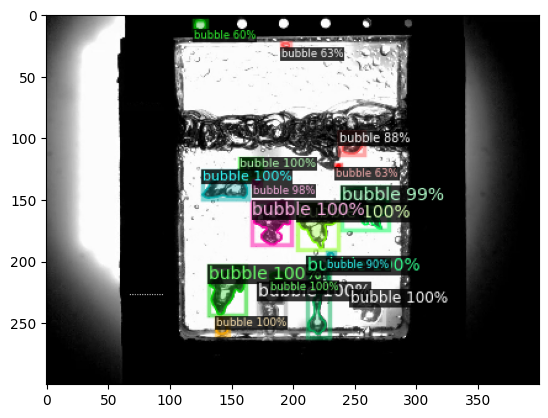

In [15]:
from detectron2.utils.visualizer import ColorMode

for d in random.sample(val_dataset_dicts, 1):    #select number of images for display
    #full = os.path.join(val_metadata.image_root, d["file_name"])
    #im = cv2.imread(full)
    im = cv2.imread(d["file_name"])
    outputs = predictor(im)
    v = Visualizer(im[:, :, ::-1],
                   metadata=val_metadata,
                   scale=0.5,
                   instance_mode=ColorMode.IMAGE_BW   # remove the colors of unsegmented pixels. This option is only available for segmentation models
    )
    out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
    plt.imshow(out.get_image()[:,:,::-1])
    #cv2.imshow(out.get_image()[:, :, ::-1])

In [16]:
outputs

{'instances': Instances(num_instances=17, image_height=600, image_width=800, fields=[pred_boxes: Boxes(tensor([[275.3823, 492.3709, 295.3511, 519.9424],
         [253.0110, 253.8497, 327.0476, 300.3219],
         [263.9019, 407.7368, 324.6205, 488.2019],
         [493.3719, 448.1366, 547.4431, 502.1104],
         [363.1745, 418.4396, 388.3499, 433.8239],
         [343.5850, 436.3113, 387.6378, 524.7853],
         [408.0338, 307.6633, 473.8649, 381.2571],
         [314.8947, 234.4804, 350.7902, 268.0922],
         [423.5013, 394.7752, 459.3735, 523.4582],
         [334.9504, 304.1620, 398.5818, 374.2028],
         [479.1710, 280.0694, 556.1663, 349.3705],
         [335.7403, 267.8958, 347.7725, 277.7522],
         [456.8733, 386.7527, 467.7894, 397.4407],
         [476.5269, 192.7121, 515.0995, 228.3072],
         [381.5359,  46.4728, 395.3454,  56.6376],
         [470.8125, 244.2750, 477.9573, 250.1844],
         [240.0962,  10.1470, 259.1807,  26.3847]], device='cuda:0')), scores: ten

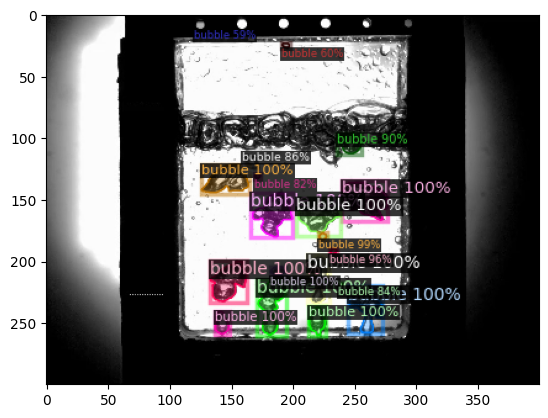

In [17]:
from detectron2.utils.visualizer import ColorMode
import matplotlib.pyplot as plt

im = cv2.imread('C:/BLENDER/BubbleID/Code/Bubblina/Validation Frames/frame_3794.jpg') # C:/BLENDER/Bubble ID Test/Fancy Ant Data/Validation Frames/FancyAnt_80_frame_1008.jpg

outputs = predictor(im)
v = Visualizer(im[:, :, ::-1],
               metadata=val_metadata,
               scale=0.5,
               instance_mode=ColorMode.IMAGE_BW   # remove the colors of unsegmented pixels. This option is only available for segmentation models
)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
plt.imshow(out.get_image()[:,:,::-1])


In [18]:
outputs

{'instances': Instances(num_instances=19, image_height=600, image_width=800, fields=[pred_boxes: Boxes(tensor([[425.4089, 474.3771, 453.1527, 521.8654],
         [406.7171, 298.9768, 478.7818, 359.8286],
         [479.4923, 270.7122, 554.0309, 335.6353],
         [490.6276, 440.9952, 546.9417, 517.4468],
         [252.1555, 243.2052, 329.5973, 292.0204],
         [265.3968, 400.8356, 325.6122, 468.4481],
         [332.4518, 290.5898, 400.1906, 362.0480],
         [423.7025, 389.9508, 460.5139, 470.6317],
         [342.5379, 430.0047, 389.2819, 521.3205],
         [273.0390, 481.5474, 297.3022, 520.7242],
         [364.0430, 409.3019, 388.3644, 425.8670],
         [442.1527, 354.9760, 455.4922, 366.5597],
         [460.4722, 379.7468, 472.1039, 390.7278],
         [472.5985, 193.2781, 512.4559, 228.4646],
         [318.2003, 224.3509, 349.6147, 255.9504],
         [474.6894, 435.7340, 481.8431, 441.7886],
         [337.9451, 258.8183, 348.1933, 267.5429],
         [381.5608,  46.4708, 3

In [19]:
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader
evaluator=COCOEvaluator("my_dataset_test", output_dir='./help') # my_dataset_val
val_loader=build_detection_test_loader(cfg, "my_dataset_test") # my_dataset_val
print(inference_on_dataset(predictor.model,val_loader, evaluator))

[10/23 15:41:06 d2.evaluation.coco_evaluation]: Fast COCO eval is not built. Falling back to official COCO eval.
[10/23 15:41:06 d2.data.datasets.coco]: Loaded 23 images in COCO format from C:/BLENDER/Bubble ID Test/Labels/SaveData/validation_Bubblina_bubble_coco.json
[10/23 15:41:06 d2.data.build]: Distribution of instances among all 1 categories:
|  category  | #instances   |
|:----------:|:-------------|
|   bubble   | 256          |
|            |              |
[10/23 15:41:06 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(1000, 1000), max_size=1333, sample_style='choice')]
[10/23 15:41:06 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[10/23 15:41:06 d2.data.common]: Serializing 23 elements to byte tensors and concatenating them all ...
[10/23 15:41:06 d2.data.common]: Serialized dataset takes 0.16 MiB
[10/23 15:41:06 d2.evaluation.evaluator]: Start inference o

In [20]:
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader
evaluator=COCOEvaluator("my_dataset_test", output_dir='./help') # my_dataset_val
val_loader=build_detection_test_loader(cfg, "my_dataset_test")
print(inference_on_dataset(predictor.model,val_loader, evaluator)) # my_dataset_val

[10/23 15:41:14 d2.evaluation.coco_evaluation]: Fast COCO eval is not built. Falling back to official COCO eval.
[10/23 15:41:14 d2.data.datasets.coco]: Loaded 23 images in COCO format from C:/BLENDER/Bubble ID Test/Labels/SaveData/validation_Bubblina_bubble_coco.json
[10/23 15:41:14 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(1000, 1000), max_size=1333, sample_style='choice')]
[10/23 15:41:14 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[10/23 15:41:14 d2.data.common]: Serializing 23 elements to byte tensors and concatenating them all ...
[10/23 15:41:14 d2.data.common]: Serialized dataset takes 0.16 MiB
[10/23 15:41:14 d2.evaluation.evaluator]: Start inference on 23 batches
[10/23 15:41:20 d2.evaluation.evaluator]: Inference done 11/23. Dataloading: 0.0005 s/iter. Inference: 0.0799 s/iter. Eval: 0.0130 s/iter. Total: 0.0934 s/iter. ETA=0:00:01
[10/23 15:41:22 

In [21]:
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader
evaluator=COCOEvaluator("my_dataset_test", output_dir='./help') # my_dataset_val
val_loader=build_detection_test_loader(cfg, "my_dataset_test") # my_dataset_val
print(inference_on_dataset(predictor.model,val_loader, evaluator))

[10/23 15:41:22 d2.evaluation.coco_evaluation]: Fast COCO eval is not built. Falling back to official COCO eval.
[10/23 15:41:22 d2.data.datasets.coco]: Loaded 23 images in COCO format from C:/BLENDER/Bubble ID Test/Labels/SaveData/validation_Bubblina_bubble_coco.json
[10/23 15:41:22 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(1000, 1000), max_size=1333, sample_style='choice')]
[10/23 15:41:22 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[10/23 15:41:22 d2.data.common]: Serializing 23 elements to byte tensors and concatenating them all ...
[10/23 15:41:22 d2.data.common]: Serialized dataset takes 0.16 MiB
[10/23 15:41:23 d2.evaluation.evaluator]: Start inference on 23 batches
[10/23 15:41:28 d2.evaluation.evaluator]: Inference done 11/23. Dataloading: 0.0006 s/iter. Inference: 0.0798 s/iter. Eval: 0.0132 s/iter. Total: 0.0936 s/iter. ETA=0:00:01
[10/23 15:41:30 